In [1]:
import pandas as pd

df = pd.read_csv("../data/spam.csv", encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "texte"]

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   texte   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [3]:
print("Valeurs manquantes :")
print(df.isnull().sum())
print()
print("Nombre de doublons :", df.duplicated().sum())

Valeurs manquantes :
label    0
texte    0
dtype: int64

Nombre de doublons : 403


In [4]:
print(df["label"].value_counts())
print()
print((df["label"].value_counts(normalize=True) * 100).round(1))

label
ham     4825
spam     747
Name: count, dtype: int64

label
ham     86.6
spam    13.4
Name: proportion, dtype: float64


In [5]:
print("--- 3 exemples de HAM (message légitime) ---")
for t in df[df["label"] == "ham"]["texte"].head(3):
    print("•", t)

print()
print("--- 3 exemples de SPAM ---")
for t in df[df["label"] == "spam"]["texte"].head(3):
    print("•", t)

--- 3 exemples de HAM (message légitime) ---
• Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
• Ok lar... Joking wif u oni...
• U dun say so early hor... U c already then say...

--- 3 exemples de SPAM ---
• Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
• FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
• WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


In [6]:
df = df.drop_duplicates().reset_index(drop=True)

print("Nouvelles dimensions :", df.shape)
print()
print(df["label"].value_counts())
print()
print((df["label"].value_counts(normalize=True) * 100).round(1))

Nouvelles dimensions : (5169, 2)

label
ham     4516
spam     653
Name: count, dtype: int64

label
ham     87.4
spam    12.6
Name: proportion, dtype: float64


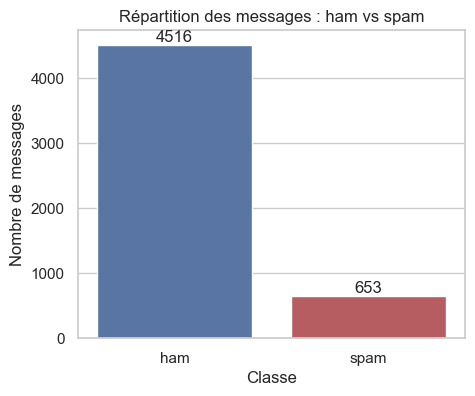

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="label", hue="label", palette=["#4C72B0", "#C44E52"], legend=False)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.title("Répartition des messages : ham vs spam")
plt.xlabel("Classe")
plt.ylabel("Nombre de messages")
plt.show()

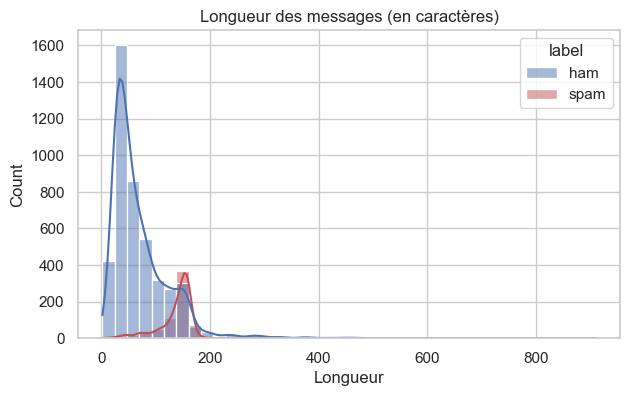

        count   mean   std   min    25%    50%    75%    max
label                                                       
ham    4516.0   70.5  56.4   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.9  30.1  13.0  132.0  149.0  157.0  224.0


In [8]:
df["longueur"] = df["texte"].str.len()

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="longueur", hue="label", bins=40, kde=True,
             palette={"ham": "#4C72B0", "spam": "#C44E52"})
plt.title("Longueur des messages (en caractères)")
plt.xlabel("Longueur")
plt.show()

print(df.groupby("label")["longueur"].describe().round(1))

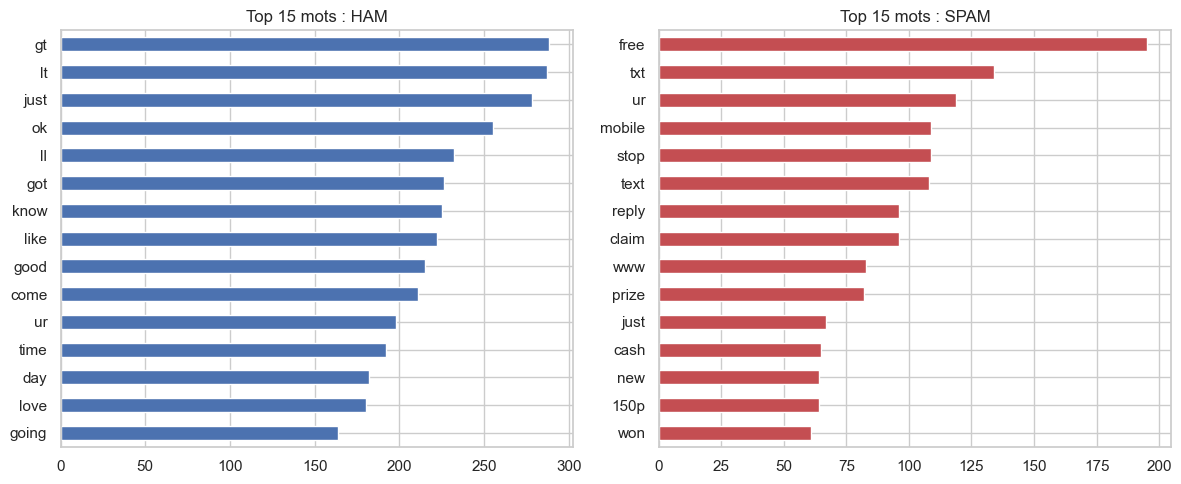

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

def top_mots(classe, n=15):
    textes = df[df["label"] == classe]["texte"]
    cv = CountVectorizer(stop_words="english")
    mat = cv.fit_transform(textes)
    freq = mat.sum(axis=0).A1
    mots = cv.get_feature_names_out()
    return pd.Series(freq, index=mots).sort_values(ascending=False).head(n)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_mots("ham").sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 15 mots : HAM")
top_mots("spam").sort_values().plot.barh(ax=axes[1], color="#C44E52")
axes[1].set_title("Top 15 mots : SPAM")
plt.tight_layout()
plt.show()

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))
print("Nombre de stop words :", len(stop_words))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...


Nombre de stop words : 198


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [11]:
def nettoyer(texte):
    texte = texte.lower()                           # minuscules
    texte = re.sub(r"&lt;|&gt;|&amp;", " ", texte)  # restes de codes HTML (gt, lt)
    texte = re.sub(r"[^a-z\s]", " ", texte)         # supprime chiffres, ponctuation, caractères spéciaux
    texte = re.sub(r"\s+", " ", texte).strip()      # espaces multiples
    return texte

def tokeniser(texte):
    mots = word_tokenize(texte)
    return [m for m in mots if m not in stop_words and len(m) > 1]

df["texte_propre"] = df["texte"].apply(nettoyer)
df["tokens"] = df["texte_propre"].apply(tokeniser)
df["texte_final"] = df["tokens"].apply(" ".join)

# Avant / après sur 3 messages spam
for i in df[df["label"] == "spam"].head(3).index:
    print("AVANT  :", df.loc[i, "texte"])
    print("APRÈS  :", df.loc[i, "texte_final"])
    print("TOKENS :", df.loc[i, "tokens"][:8], "...")
    print()

AVANT  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
APRÈS  : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate apply
TOKENS : ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final'] ...

AVANT  : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
APRÈS  : freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv
TOKENS : ['freemsg', 'hey', 'darling', 'week', 'word', 'back', 'like', 'fun'] ...

AVANT  : WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
APRÈS  : winner valued network customer selected receivea prize reward claim call claim code kl valid hours
TOKENS : ['winner', 'valued', 'network', 'cus

In [12]:
vides = (df["texte_final"].str.len() == 0).sum()
print("Messages vides après nettoyage :", vides)

Messages vides après nettoyage : 12


In [13]:
vides_df = df[df["texte_final"].str.len() == 0]
print(vides_df["label"].value_counts())
print()
for t in vides_df["texte"]:
    print("•", t)

label
ham    12
Name: count, dtype: int64

• What you doing?how are you?
• K I'll be there before 4.
• Where @
• U too...
• 645
• Can a not?
• :) 
• G.W.R
• :( but your not here....
• :-) :-)
• Same to u...
• U 2.


In [14]:
from sklearn.model_selection import train_test_split

# Retirer les messages vides
df = df[df["texte_final"].str.len() > 0].reset_index(drop=True)

# Encoder la cible : ham = 0, spam = 1
df["y"] = (df["label"] == "spam").astype(int)

X = df["texte_final"]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # garde les mêmes proportions de spam dans train et test
    random_state=42    # rend le résultat reproductible
)

print("Train :", X_train.shape[0], "messages")
print("Test  :", X_test.shape[0], "messages")
print()
print("% spam dans train :", round(y_train.mean() * 100, 1))
print("% spam dans test  :", round(y_test.mean() * 100, 1))

Train : 4125 messages
Test  : 1032 messages

% spam dans train : 12.7
% spam dans test  : 12.7


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,    # garde les 5000 termes les plus utiles
    ngram_range=(1, 2),   # mots seuls ET paires de mots (ex : "call now")
    min_df=2              # ignore les termes présents dans un seul message
)

# On apprend le vocabulaire sur le TRAIN uniquement
X_train_tfidf = tfidf.fit_transform(X_train)

# Sur le test, on applique seulement (pas de fit !)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf :", X_train_tfidf.shape)
print("X_test_tfidf  :", X_test_tfidf.shape)
print("Taille du vocabulaire :", len(tfidf.get_feature_names_out()))

X_train_tfidf : (4125, 5000)
X_test_tfidf  : (1032, 5000)
Taille du vocabulaire : 5000


In [16]:
import numpy as np

mots = tfidf.get_feature_names_out()

def top_tfidf(classe, n=12):
    masque = (y_train == classe).values
    moyenne = np.asarray(X_train_tfidf[masque].mean(axis=0)).ravel()
    idx = moyenne.argsort()[::-1][:n]
    return [(mots[i], round(moyenne[i], 3)) for i in idx]

print("--- Termes les plus pondérés : HAM ---")
for m, v in top_tfidf(0):
    print(f"{m:15s} {v}")

print()
print("--- Termes les plus pondérés : SPAM ---")
for m, v in top_tfidf(1):
    print(f"{m:15s} {v}")

--- Termes les plus pondérés : HAM ---
ok              0.017
get             0.014
come            0.013
like            0.012
know            0.012
got             0.012
good            0.011
go              0.011
time            0.01
going           0.01
call            0.01
home            0.01

--- Termes les plus pondérés : SPAM ---
call            0.057
free            0.042
txt             0.03
text            0.027
stop            0.027
mobile          0.027
reply           0.026
claim           0.025
ur              0.023
prize           0.023
www             0.02
new             0.019


In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modeles = {
    "Naive Bayes": MultinomialNB(),
    "SVM linéaire": LinearSVC(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
    "Régression logistique": LogisticRegression(class_weight="balanced", max_iter=1000),
}

resultats = []
predictions = {}

for nom, modele in modeles.items():
    modele.fit(X_train_tfidf, y_train)
    y_pred = modele.predict(X_test_tfidf)
    predictions[nom] = y_pred
    resultats.append({
        "Modèle": nom,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Précision (spam)": precision_score(y_test, y_pred),
        "Rappel (spam)": recall_score(y_test, y_pred),
        "F1 (spam)": f1_score(y_test, y_pred),
    })

tableau = pd.DataFrame(resultats).set_index("Modèle").round(3)
tableau.sort_values("F1 (spam)", ascending=False)

,Accuracy,Précision (spam),Rappel (spam),F1 (spam)
Modèle,,,,
SVM linéaire,0.984,0.939,0.939,0.939
Régression logistique,0.973,0.871,0.924,0.896
Random Forest,0.971,0.981,0.786,0.873
Naive Bayes,0.971,0.990,0.779,0.872


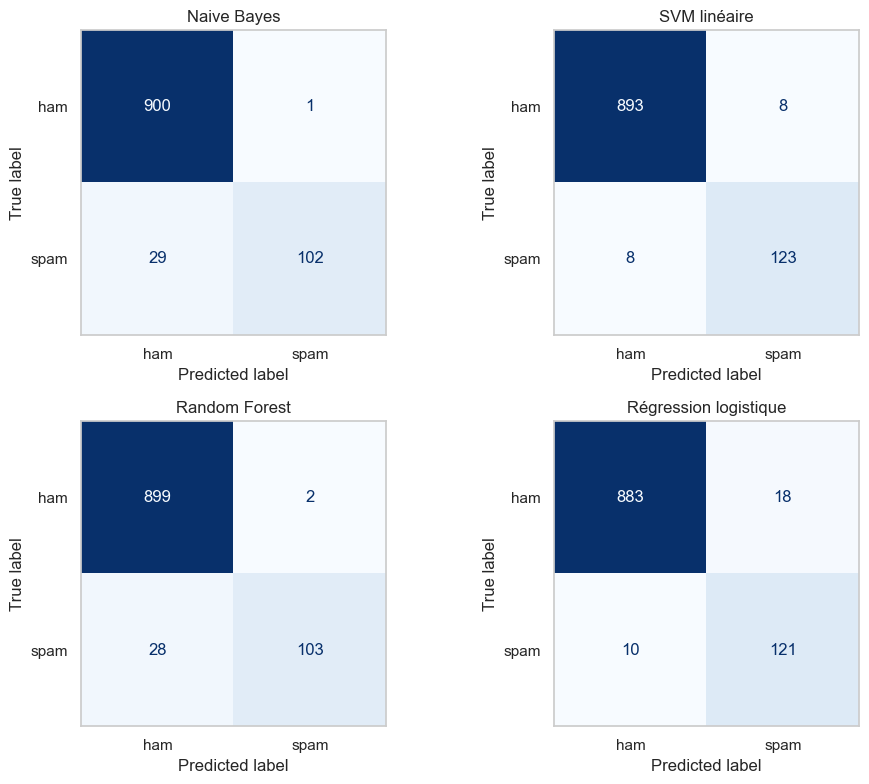

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (nom, y_pred) in zip(axes.ravel(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom)
    ax.grid(False)

plt.tight_layout()
plt.show()

In [19]:
X_test_texte = df.loc[X_test.index, "texte"]

def afficher_erreurs(nom, n=6):
    y_pred = predictions[nom]
    erreurs = pd.DataFrame({
        "texte": X_test_texte.values,
        "vrai": y_test.values,
        "predit": y_pred
    })
    faux_pos = erreurs[(erreurs["vrai"] == 0) & (erreurs["predit"] == 1)]
    faux_neg = erreurs[(erreurs["vrai"] == 1) & (erreurs["predit"] == 0)]

    print(f"===== {nom} =====")
    print(f"\nFAUX POSITIFS (ham classés spam) : {len(faux_pos)}")
    for t in faux_pos["texte"].head(n):
        print("•", t[:150])
    print(f"\nFAUX NÉGATIFS (spams non détectés) : {len(faux_neg)}")
    for t in faux_neg["texte"].head(n):
        print("•", t[:150])
    print()

afficher_erreurs("SVM linéaire")
afficher_erreurs("Naive Bayes")

===== SVM linéaire =====

FAUX POSITIFS (ham classés spam) : 8
• Hi, Mobile no.  &lt;#&gt;  has added you in their contact list on www.fullonsms.com It s a great place to send free sms to people For more visit fullo
• I am waiting machan. Call me once you free.
• Plz note: if anyone calling from a mobile Co. &amp; asks u to type # &lt;#&gt;  or # &lt;#&gt; . Do not do so. Disconnect the call,coz it iz an attemp
• I (Career Tel) have added u as a contact on INDYAROCKS.COM to send FREE SMS. To remove from phonebook - sms NO to  &lt;#&gt;
• U can call now...
• We live in the next  &lt;#&gt; mins

FAUX NÉGATIFS (spams non détectés) : 8
• Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min
• Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msg
• You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750
• ringtoneking 84484
• Mi